# Свой поисковый эмбеддер под домен + LLM-судья

Началось с бытового. У меня лежит несколько тысяч сохранённых статей, заметок, мыслей, ссылок и найти в них ничего нельзя: Ctrl+F ищет точное слово, а я помню смысл, а не
формулировку. Поставил готовый эмбеддер — стало лучше, но всё равно мимо. Понятно
почему: модели общего назначения отвечают на вопрос «похожи ли эти два текста», а мне
нужен другой — «есть ли в этом тексте ответ на мой». Значит, надо дообучать под себя.

И тут стена: для дообучения нужны пары «запрос — правильный документ», а у меня их нет.
Размечать десять тысяч пар руками я не сяду. Мысль напрашивается сама — пусть размечает
модель. Погуглил: у этого есть имя, LLM-as-a-judge, и так делают все подряд. Смутило
другое — насколько такой судья согласен с живым асессором, почти никто не пишет. Ставят
и верят.

Отсюда проект и два его вопроса: **сколько на самом деле даёт дообучение под домен** и
**можно ли доверить разметку модели** — с числом согласия на руках, а не на ощупь.

Проверять это на своих заметках нельзя: там нет разметки, а значит, нечем мерить.
Поэтому стенд — русская часть MIRACL. Задача та же (вопрос на естественном языке →
нужный абзац), но с человеческими метками, причём с обеих сторон: и релевантные пары, и
проверенно нерелевантные. На первых обучаемся, на вторых ловим судью за руку.

Всё считалось на одном MacBook (Apple Silicon, 16 ГБ). Числа из литературы помечены
**[ОЦЕНКА]**.

In [1]:
import json
import math
import os
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, os.getcwd())
import nova
import retrieval as R
import analysis as A
import judge as J

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 9

print("устройство:", nova.get_device(), "| torch", torch.__version__)

устройство: mps | torch 2.13.0


## 1. Данные

**MIRACL** ([arXiv:2210.09984](https://arxiv.org/abs/2210.09984)): носители языка
писали вопросы к статьям Википедии, асессоры размечали, содержит ли пассаж ответ.
Разметка бинарная; таблица «запрос → документ → оценка» называется **qrels**.

Нерелевантные пары там не случайные: документ попадал на разметку, если его достала
какая-то поисковая система. То есть это близкие по теме документы, которые человек
посмотрел и забраковал, — материал и для калибровки судьи, и для экспериментов с
негативами.

In [2]:
sp = nova.load_splits()
docids, passages = nova.load_mini_corpus()
by_id = dict(zip(docids, passages))
qrels_dev = sp["qrels"]["dev"]
topics = sp["topics"]

print(f"полный корпус MIRACL-ru:   {sp['full_corpus_size']:,} пассажей")
print(f"мини-корпус:               {sp['corpus_size']:,} "
      f"({100 * sp['corpus_size'] / sp['full_corpus_size']:.2f}% от полного)")
print(f"   из разметки:            {sp['n_judged_docs']:,}")
print(f"   случайных дистракторов: {sp['n_distractors']:,}")
print(f"\nзапросов: train {len(sp['train_qids']):,} | "
      f"valid {len(sp['valid_qids']):,} | test {len(sp['test_qids']):,}")

полный корпус MIRACL-ru:   9,543,918 пассажей
мини-корпус:               150,000 (1.57% от полного)
   из разметки:            41,007
   случайных дистракторов: 108,993

запросов: train 4,683 | valid 299 | test 947


### Как собран мини-корпус

Полный корпус — 9.5 миллиона пассажей, на ноутбуке не живёт. Беру **все** документы из
разметки (иначе у запроса пропадут правильные ответы) и добираю случайных дистракторов
до 150 тысяч через **reservoir sampling** — выбор N случайных элементов за один проход
по потоку. Корпус отсортирован по статьям, иначе вышел бы тематический перекос.

Три оговорки. **Абсолютные числа несравнимы с лидербордом** — корпус урезан в 64 раза,
сколько это стоит, в разделе 3. **Dev поделён на valid (300) и test:** подбираю всё на
valid, финальные числа считаю на test один раз. **Сплиты разведены по id запроса, но не
по тексту** — дословные дубли train выкинул.

In [3]:
for split, items in sp.get("dropped_duplicates", {}).items():
    print(f"выкинуто из {split}: {len(items)}")
    for it in items:
        print(f"    {it['query']}")

выкинуто из valid: 1
    Откуда пошла фраза: "В Багдаде все спокойно"?
выкинуто из test: 5
    Когда началась Вели́кая Оте́чественная война́?
    Как звали верховного Бога викингов?
    По какому озеру проходила "Дорога жизни"?
    Когда пал "железный занавес"?
    Кто автор памятника «Рабо́чий и колхо́зница»?


In [4]:
ex_q = sp["test_qids"][7]
ex_gold = [d for d, r in qrels_dev[ex_q].items() if r > 0]
ex_neg = [d for d, r in qrels_dev[ex_q].items() if r == 0]
print(f"ЗАПРОС: {topics[ex_q]}\n")
print(f"РЕЛЕВАНТНЫЙ [{ex_gold[0]}]:\n  {by_id[ex_gold[0]][:380]}\n")
if ex_neg:
    print(f"НЕРЕЛЕВАНТНЫЙ, проверено человеком [{ex_neg[0]}]:\n  {by_id[ex_neg[0]][:380]}")

ЗАПРОС: Занималось Бюро шифров взломом шифров немецкой Энигмы?

РЕЛЕВАНТНЫЙ [2770431#16]:
  Бюро шифров. Главным ведомством Бюро и отделением, ответственным за криптоанализ немецких систем шифрования, стало BS4, позже основной задачей отделения стал взлом немецкой шифровальной машины «Энигма». Начальником немецкого отделения (BS4) и заместителем начальника Бюро шифров стал капитан , который в 1946 году получил звание подполковника. Одними из ключевых специалистов, раб

НЕРЕЛЕВАНТНЫЙ, проверено человеком [2770431#12]:
  Бюро шифров. В 1930 году польское командование приняло решение закрыть курс и создать секретную разведывательную организацию. В середине 1931 года в польском Генштабе в результате слияния сектора радиоразведки () и сектора польских шифров () было образовано Бюро шифров. В круг его задач входили как работа над криптографией (использованием шифров и кодов), так и работа над крипт


длина пассажа, символов: медиана 334, p90 933, p99 1827
релевантных на тестовый запрос: медиана 2, среднее 2.82, максимум 12


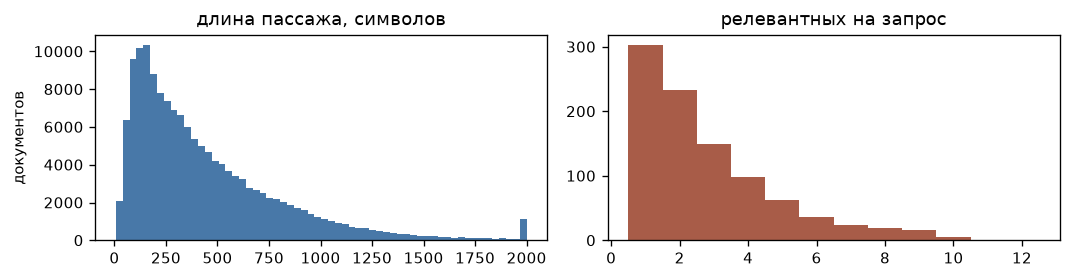

In [5]:
lens = np.array([len(p) for p in passages])
n_pos = [sum(1 for r in qrels_dev[q].values() if r > 0) for q in sp["test_qids"]]
print(f"длина пассажа, символов: медиана {int(np.median(lens))}, "
      f"p90 {int(np.percentile(lens, 90))}, p99 {int(np.percentile(lens, 99))}")
print(f"релевантных на тестовый запрос: медиана {int(np.median(n_pos))}, "
      f"среднее {np.mean(n_pos):.2f}, максимум {max(n_pos)}")

fig, ax = plt.subplots(1, 2, figsize=(9, 2.4))
ax[0].hist(np.clip(lens, 0, 2000), bins=60, color="#4878a8")
ax[0].set_title("длина пассажа, символов"); ax[0].set_ylabel("документов")
ax[1].hist(n_pos, bins=range(1, 14), color="#a85c48", align="left")
ax[1].set_title("релевантных на запрос")
plt.tight_layout(); plt.show()

## 2. Метрики

На этих четырёх числах держится весь проект, поэтому пишу их руками и сверяю с
эталоном: в NDCG легко ошибиться незаметно — обрезать идеальный порядок не по k, забыть
про релевантные документы, которые вообще не нашлись, — и все сравнения тихо поедут.
Везде `ranked` — документы по убыванию скора, `rel_map` — разметка запроса вида
«документ → оценка».

**Recall@k** — доля релевантных документов запроса в топ-k. **MRR@k** — обратная
позиция первого релевантного. **NDCG@k** — основная метрика качества выдачи:

$$\text{DCG@}k = \sum_{i=1}^{k} \frac{2^{rel_i} - 1}{\log_2(i + 1)}, \qquad
\text{NDCG@}k = \frac{\text{DCG@}k}{\text{IDCG@}k}$$

Вклад документа падает с позицией; деление на IDCG (тот же DCG для идеального порядка)
нормирует результат в [0, 1]. У MIRACL релевантность бинарная, так что NDCG различает
подходы только по позициям.

In [6]:
def dcg_at_k(gains, k):
    """DCG@k. Индексация с нуля, поэтому log2(i+2), а не log2(i+1)."""
    return sum((2.0 ** g - 1.0) / math.log2(i + 2) for i, g in enumerate(gains[:k]))


def ndcg_at_k(ranked, rel_map, k):
    gains = [rel_map.get(d, 0) for d in ranked[:k]]
    idcg = dcg_at_k(sorted(rel_map.values(), reverse=True)[:k], k)   # идеальный порядок
    return dcg_at_k(gains, k) / idcg if idcg > 0 else 0.0


def recall_at_k(ranked, rel_map, k):
    positives = {d for d, r in rel_map.items() if r > 0}
    if not positives:
        return 0.0
    return sum(1 for d in ranked[:k] if d in positives) / len(positives)


def mrr_at_k(ranked, rel_map, k):
    for i, d in enumerate(ranked[:k]):
        if rel_map.get(d, 0) > 0:
            return 1.0 / (i + 1)
    return 0.0

In [7]:
# Сверяю с ручным счётом и sklearn — при бинарной релевантности все три обязаны совпасть.
# Плюс края, на которых метрики любят молча ломаться.
from sklearn.metrics import ndcg_score

ranked = ["d1", "d2", "d3", "d4", "d5"]
rel = {"d1": 0, "d2": 1, "d3": 0, "d4": 1, "d5": 0, "d9": 1}    # d9 не нашёлся

manual = ((1 / math.log2(3) + 1 / math.log2(5)) /                        # позиции 2 и 4
          (1 / math.log2(2) + 1 / math.log2(3) + 1 / math.log2(4)))      # идеал
alldocs = ["d1", "d2", "d3", "d4", "d5", "d9"]
sk = ndcg_score(np.array([[rel[d] for d in alldocs]]), np.array([[5, 4, 3, 2, 1, 0]]), k=5)

print(f"NDCG@5:  моя реализация {ndcg_at_k(ranked, rel, 5):.6f} | "
      f"вручную {manual:.6f} | sklearn {sk:.6f}")
print(f"Recall@3 = {recall_at_k(ranked, rel, 3):.4f}  (нашли 1 из 3 релевантных)")
print(f"MRR@5    = {mrr_at_k(ranked, rel, 5):.4f}  (первый релевантный на позиции 2)")

assert abs(ndcg_at_k(ranked, rel, 5) - sk) < 1e-9
assert abs(recall_at_k(ranked, rel, 3) - 1 / 3) < 1e-9
assert abs(mrr_at_k(ranked, rel, 5) - 0.5) < 1e-9

print("\nкрая:")
print("  идеальный порядок      NDCG@5 =", round(ndcg_at_k(["d2", "d4", "d9", "d1", "d3"], rel, 5), 4))
print("  ни одного релевантного NDCG@5 =", round(ndcg_at_k(["d1", "d3", "d5"], rel, 5), 4))
print("  пустая разметка        NDCG@5 =", round(ndcg_at_k(ranked, {}, 5), 4))

NDCG@5:  моя реализация 0.498189 | вручную 0.498189 | sklearn 0.498189
Recall@3 = 0.3333  (нашли 1 из 3 релевантных)
MRR@5    = 0.5000  (первый релевантный на позиции 2)

края:
  идеальный порядок      NDCG@5 = 1.0
  ни одного релевантного NDCG@5 = 0.0
  пустая разметка        NDCG@5 = 0.0


## 3. Бейзлайны

**BM25** — лексический поиск: слово тем важнее, чем чаще оно в документе и реже в
коллекции. Библиотека `bm25s`, токенизация — стоп-слова плюс стеммер Snowball,
сводящий «кризиса», «кризисом», «кризисы» к одной основе.

**Плотный поиск без дообучения.** `rubert-tiny2` — 29M параметров, обучалась на близость
предложений, а не на поиск. Дообучаем именно её: по исходной задаче модель должна жить
на моей же машине рядом с корпусом, а 29M ещё и обучаются за пару минут — значит за
вечер проверяется не одна гипотеза, а полтора десятка. `multilingual-e5-small` — 118M,
обучена под retrieval: то, что я и поставил бы с полки, не начиная всё это (префиксы
`query: ` / `passage: ` обязательны).

In [8]:
res = nova.load_json(nova.RESULTS_PATH)

LABEL = {
    "BM25": "BM25",
    "rubert-tiny2, zero-shot": "rubert-tiny2, без дообучения",
    "multilingual-e5-small, zero-shot": "multilingual-e5-small, без дообучения",
    "ft_inbatch_bs16": "дообучен, батч 16",
    "ft_inbatch_bs64": "дообучен, негативы только из батча (батч 64)",
    "ft_inbatch_bs128": "дообучен, батч 128",
    "ft_inbatch_bs16_lr": "батч 16, lr 1e-5",
    "ft_inbatch_bs128_lr": "батч 128, lr 8e-5",
    "ft_inbatch_bs256_lr": "батч 256, lr 1.6e-4",
    "ft_mined_bs64": "дообучен + сложные негативы (батч 64)",
    "ft_mined_fair": "негативы намайненные",
    "ft_judged_fair": "негативы человеческие (rel=0)",
    "ft_band_6_15": "негативы с позиций 6-15 (труднее)",
    "ft_band_16_30": "негативы с позиций 16-30",
    "ft_band_31_50": "негативы с позиций 31-50 (легче)",
    "ft_best": "лучшая комбинация: полоса 16-30 + большой батч",
    "ft_inbatch_bs96": "контроль: только in-batch, тот же батч",
}


def show(names, cols=("Recall@10", "Recall@100", "NDCG@10", "MRR@10")):
    """Таблица по списку имён из results.json, в порядке этого списка."""
    rows = [{"подход": LABEL.get(n, n), **{c: res[n][c] for c in cols}}
            for n in names if n in res]
    return pd.DataFrame(rows).round(4)


show(["BM25", "rubert-tiny2, zero-shot", "multilingual-e5-small, zero-shot"])

,подход,Recall@10,Recall@100,NDCG@10,MRR@10
0,BM25,0.6504,0.8558,0.5142,0.5400
1,"rubert-tiny2, без дообучения",0.1796,0.4577,0.1335,0.1615
2,"multilingual-e5-small, без дообучения",0.8835,0.9941,0.7595,0.7905


**Проверка вменяемости пройдена:** e5-small обходит BM25 с большим запасом. Не обошла
бы — значит забыты префиксы, не нормализованы векторы или перепутаны идентификаторы.

`rubert-tiny2` проигрывает BM25 в разы, тоже ожидаемо: она училась отвечать на «эти два
текста про одно и то же?», а поиск спрашивает «есть ли в тексте ответ?». Этот разрыв и
закрывает дообучение.

In [9]:
pub = {"BM25": (0.334, 0.661), "multilingual-e5-small, zero-shot": (0.591, 0.922)}
pd.DataFrame([{
    "модель": LABEL[k],
    "NDCG@10 у нас": round(res[k]["NDCG@10"], 3), "NDCG@10 на полном корпусе": nd,
    "во сколько раз выше": round(res[k]["NDCG@10"] / nd, 2),
    "R@100 у нас": round(res[k]["Recall@100"], 3), "R@100 на полном": rc,
} for k, (nd, rc) in pub.items()])

,модель,NDCG@10 у нас,NDCG@10 на полном корпусе,во сколько раз выше,R@100 у нас,R@100 на полном
0,BM25,0.514,0.334,1.54,0.856,0.661
1,"multilingual-e5-small, без дообучения",0.759,0.591,1.29,0.994,0.922


**[ОЦЕНКА]** Правая половина — опубликованные числа на полном корпусе:
[MIRACL, Table 2](https://arxiv.org/abs/2210.09984) и
[E5, Table 6](https://arxiv.org/html/2402.05672v1).

Урезание подняло NDCG@10 в полтора раза и **одинаково для обеих моделей** — задача
стала легче, но не перекосилась. Recall@100 упёрся в потолок (0.994 у e5) и как
различитель бесполезен: дальше смотрю на NDCG@10, MRR@10 и Recall@10.

## 4. Майнинг сложных негативов

Для контрастивного обучения нужны тройки «запрос — правильный ответ — неправильный».
Случайный документ бесполезен: отличить вопрос про Кеннеди от статьи про пчеловодство
модель умеет и так. Нужны **сложные негативы** — похожие на ответ по словам или теме, но
ответа не содержащие. Беру топ-50 BM25 и топ-50 плотного поиска, склеиваю чередованием,
выкидываю размеченное как релевантное, оставляю 8. Майню **только по train-запросам** —
тут утечка возникает незаметнее всего.

In [10]:
pd.DataFrame([
    {"источник кандидатов": "BM25", "не размечен": "84.4%",
     "не размечен, но из статьи правильного ответа": "4.5%",
     "человек: нерелевантен": "7.4%", "человек: РЕЛЕВАНТЕН": "3.7%"},
    {"источник кандидатов": "плотный поиск (e5-small)", "не размечен": "80.2%",
     "не размечен, но из статьи правильного ответа": "6.7%",
     "человек: нерелевантен": "8.9%", "человек: РЕЛЕВАНТЕН": "4.2%"},
])

,источник кандидатов,не размечен,"не размечен, но из статьи правильного ответа",человек: нерелевантен,человек: РЕЛЕВАНТЕН
0,BM25,84.4%,4.5%,7.4%,3.7%
1,плотный поиск (e5-small),80.2%,6.7%,8.9%,4.2%


**~4% кандидатов — подтверждённые человеком позитивы**, их выкидываю по разметке. И
**~80% никем не размечены**: асессоры смотрели только выдачу систем, значит среди них
есть непроверенные релевантные — **ложные негативы**, главная головная боль майнинга.
Ещё выкидываю кандидатов из статьи правильного ответа: соседний пассаж слишком часто
тоже релевантен, а идентификатор вида `articleId#passageIdx` делает фильтр бесплатным.

In [11]:
train_rows = [json.loads(l) for l in
              open(os.path.join(nova.MINI, "train_pairs.jsonl"), encoding="utf-8")]
print(f"обучающих строк «запрос-позитив»: {len(train_rows):,} "
      f"по {len({r['qid'] for r in train_rows}):,} уникальным запросам\n")

r = next((x for x in train_rows if "убийцу Джона Кеннеди" in x["query"]), train_rows[0])
print(f"ЗАПРОС: {r['query']}")
print(f"\nПОЗИТИВ по разметке:\n  {by_id[r['pos']][:340]}")
for d in r["negs"][:2]:
    print(f"\nНАМАЙНЕНО КАК НЕГАТИВ [{d}]:\n  {by_id[d][:340]}")

обучающих строк «запрос-позитив»: 10,000 по 4,683 уникальным запросам

ЗАПРОС: Как звали предполагаемого убийцу Джона Кеннеди?

ПОЗИТИВ по разметке:
  Убийство Джона Кеннеди. В 1966 году окружной прокурор Нового Орлеана Джим Гаррисон начал собственное расследование убийства. Основными подозреваемыми он считал бывшего пилота авиакомпании Eastern Air Lines и новоорлеанского банкира . По его версии, убийство было организовано военизированной группой ультраправых активистов, имевшей связи с

НАМАЙНЕНО КАК НЕГАТИВ [39314#0]:
  Освальд, Ли Харви. Ли Ха́рви О́свальд (; 18 октября 1939, Новый Орлеан, Луизиана, США — 24 ноября 1963, Даллас, Техас, США) — единственный официальный подозреваемый в убийстве американского президента Джона Кеннеди. По закону США умерший не может быть судим, но по выводам Комиссии Уоррена он назван убийцей.

НАМАЙНЕНО КАК НЕГАТИВ [2087315#9]:
  Убийство Мартина Лютера Кинга. Он был первым, кто публично проинформировал людей о смерти Мартина Лютера Кинга, чем вызвал кр

Первый «негатив» — ложный: запрос про предполагаемого убийцу Кеннеди, а в негативы
попала статья про **Ли Харви Освальда**. Пары просто нет в qrels, фильтр «та же статья»
не помог — статьи разные. Поймать такое может только смысловая проверка, то есть судья
из раздела 8.

## 5. Дообучение двубашенного эмбеддера

В **двубашенной** (bi-encoder) модели запрос и документ кодируются независимо,
релевантность — скалярное произведение векторов. Корпус за счёт этого кодируется
заранее; плата — запрос и документ не видят друг друга внутри модели.

Лосс — `MultipleNegativesRankingLoss`, он же InfoNCE с негативами из батча:

## Обозначения

### $q$ — запрос

Тот самый вопрос. Из твоих данных: «Сколько лет длилась война в Афганистане?». Модель превращает его в вектор из 312 чисел.

### $p^+$ — позитив, правильный ответ

Отвечаю на твой главный вопрос: позитивы — это абзацы, которые живой асессор пометил как содержащие ответ (rel=1). Не выдуманные, не выведенные эвристикой — человеческая разметка MIRACL.

Лежат они в поле pos файла train_pairs.jsonl. Строк там 10 000, а уникальных запросов 4 683 — потому что у одного запроса бывает несколько правильных ответов, и каждый становится отдельной обучающей строкой. У афганского запроса их пять, значит он даст пять строк, в каждой свой $p^+$.

Плюсик в $p^+$ — просто пометка «этот из них правильный».

### $p$ — любой кандидат

Пробегает по всем абзацам в пуле: и по правильному, и по неправильным.

### $B$ — пул кандидатов (батч)

Вот тут вся соль. Отдельных «неправильных ответов» модели никто не подсовывает — неправильными работают правильные ответы соседних запросов в той же пачке.

Собрали пачку из 64 строк. У каждой свой запрос и свой правильный абзац. Для запроса №1 его абзац правильный, а остальные 63 — чужие, значит для него неправильные. Отсюда «negatives from batch», негативы из батча: они бесплатные, их не надо искать.

Размеры в твоём проекте:

| режим | из чего пул | сколько кандидатов | из них неправильных |
|---|---|---|---|
| только in-batch, bs=64 | 64 позитива | 64 | 63 |
| + 2 сложных негатива, bs=64 | 64 позитива + 128 негативов | 192 | 191 |

Вторая строка — это ft_mined_bs64. Отсюда же и OOM у ft_mined_bs128: 128 строк × 4 текста (запрос + позитив + 2 негатива) = 512 последовательностей в памяти одновременно.

### $s(q, p)$ — оценка близости

Модель кодирует запрос и абзац по отдельности в векторы, нормирует их на единичную длину и перемножает скалярно. Для единичных векторов это косинус угла: от −1 до +1, где 1 — «направлены одинаково».

### $\tau$ (тау) — температура

Число, на которое делят все оценки перед возведением в экспоненту. В sentence-transformers задаётся через scale=20, то есть $\tau = 1/20 = 0.05$.

Смысл: регулирует придирчивость. Косинусы лежат в узком диапазоне, различия между 0.80 и 0.70 крошечные. Деление на 0.05 растягивает их в 20 раз, и мелкая разница становится решающей.

Вот что она делает на одних и тех же кандидатах (позитив 0.80, негативы 0.70 / 0.30 / 0.10):

| $\tau$ | вероятность правильного | лосс |
|---|---|---|
| 1.0 (без температуры) | 0.3325 | 1.1013 |
| 0.2 | 0.5818 | 0.5416 |
| 0.05 (наш) | 0.8808 | 0.1270 |

## Как читается дробь

Знаменатель $\sum_{p \in B} \exp(s(q,p)/\tau)$ — сложили экспоненты оценок всех кандидатов, включая правильного. Это общий «вес» всех вариантов.

Числитель — тот же вес, но только у правильного.

Дробь — доля правильного в общем весе, то есть вероятность, что модель выберет именно его. Это и есть softmax. Число от 0 до 1.

Логарифм и минус. У правильного ответа мы хотим вероятность 1. $\log(1) = 0$, а минус превращает это в ноль штрафа. Если вероятность 0.5, то $-\log(0.5) = 0.69$. Если 0.01 — $-\log(0.01) = 4.6$. Чем хуже, тем больнее, причём нелинейно.

$\mathcal{L}$ — сам штраф, его и минимизируют.

$$\mathcal{L} = -\log \frac{\exp(s(q, p^+) / \tau)}{\sum_{p \in B} \exp(s(q, p) / \tau)}$$

В знаменателе позитивы всех остальных запросов батча — для нашего запроса они и есть
негативы. Отсюда прямая зависимость от размера батча.

**Подводный камень:** у запроса бывает несколько релевантных пассажей, и если две такие
строки попадут в один батч, лосс посчитает позитив соседней негативом. Лечится
сэмплером `NO_DUPLICATES`.

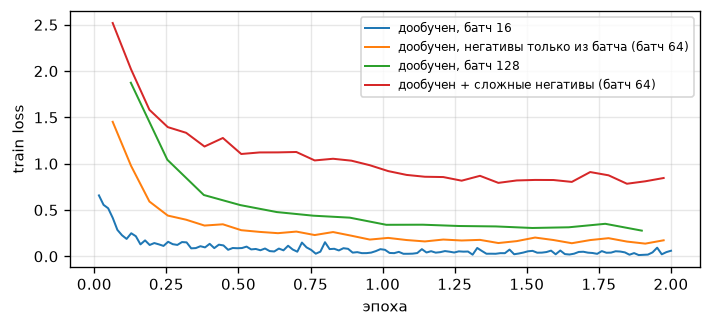

In [12]:
def trainlog(name):
    p = os.path.join(nova.MODELS, name, "trainlog.json")
    return nova.load_json(p) if os.path.exists(p) else None


logs = {n: lg for n in ["ft_inbatch_bs16", "ft_inbatch_bs64", "ft_inbatch_bs128",
                        "ft_mined_bs64"] if (lg := trainlog(n))}

plt.figure(figsize=(6, 2.8))
for name, lg in logs.items():
    hist = lg["log_history"]
    plt.plot([h["epoch"] for h in hist], [h["loss"] for h in hist],
             label=f"{LABEL.get(name, name)}", linewidth=1.2)
plt.xlabel("эпоха"); plt.ylabel("train loss"); plt.grid(alpha=0.3)
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

Лоссы при разном батче несравнимы: больше негативов в знаменателе — задача формально
труднее, лосс при том же качестве выше. Сравнивать надо по метрикам.

In [13]:
show(["rubert-tiny2, zero-shot", "BM25", "ft_inbatch_bs64", "ft_mined_bs64",
      "multilingual-e5-small, zero-shot"])

,подход,Recall@10,Recall@100,NDCG@10,MRR@10
0,"rubert-tiny2, без дообучения",0.1796,0.4577,0.1335,0.1615
1,BM25,0.6504,0.8558,0.5142,0.5400
2,"дообучен, негативы только из батча (батч 64)",0.6699,0.8887,0.5369,0.5903
3,дообучен + сложные негативы (батч 64),0.6869,0.8898,0.5533,0.6063
4,"multilingual-e5-small, без дообучения",0.8835,0.9941,0.7595,0.7905


Разница в третьем знаке на 947 запросах может быть шумом, поэтому считаю **парный
бутстреп**: пересэмплирую сами запросы с возвратом и смотрю распределение средней
разницы. Парный — обе системы меряются на одних запросах.

In [14]:
def compare(a, b, k=10):
    keep = set(sp["test_qids"])
    runs = {n: {q: v for q, v in R.load_run(res[n].get("tag", n), "test").items() if q in keep}
            for n in (a, b)}
    pq = {n: nova.per_query_metric(runs[n], qrels_dev, "ndcg", k) for n in (a, b)}
    d, lo, hi = nova.bootstrap_ci(pq[a], pq[b])
    return {"A": LABEL.get(a, a), "B": LABEL.get(b, b), f"ΔNDCG@{k}": round(d, 4),
            "95% интервал": f"[{lo:+.4f}, {hi:+.4f}]",
            "вывод": "значимо" if (lo > 0 or hi < 0) else "в пределах шума"}


pd.DataFrame([compare(a, b) for a, b in [
    ("rubert-tiny2, zero-shot", "ft_inbatch_bs64"),
    ("BM25", "ft_inbatch_bs64"),
    ("ft_inbatch_bs64", "ft_mined_bs64"),
    ("ft_mined_bs64", "multilingual-e5-small, zero-shot"),
] if a in res and b in res])

,A,B,ΔNDCG@10,95% интервал,вывод
0,"rubert-tiny2, без дообучения","дообучен, негативы только из батча (батч 64)",0.4035,"[+0.3822, +0.4251]",значимо
1,BM25,"дообучен, негативы только из батча (батч 64)",0.0227,"[-0.0026, +0.0477]",в пределах шума
2,"дообучен, негативы только из батча (батч 64)",дообучен + сложные негативы (батч 64),0.0163,"[+0.0078, +0.0246]",значимо
3,дообучен + сложные негативы (батч 64),"multilingual-e5-small, без дообучения",0.2062,"[+0.1864, +0.2263]",значимо


### Размер батча: как я сам сломал эксперимент

Размер батча в MNRL — буквально количество негативов, так что ожидание «больше батч →
лучше». При фиксированном lr 4e-5 вышло обратное:

In [15]:
show(["ft_inbatch_bs16", "ft_inbatch_bs64", "ft_inbatch_bs128"], cols=("NDCG@10", "MRR@10"))

,подход,NDCG@10,MRR@10
0,"дообучен, батч 16",0.5391,0.5903
1,"дообучен, негативы только из батча (батч 64)",0.5369,0.5903
2,"дообучен, батч 128",0.5324,0.5845


Результат против всей литературы, так что подозрение падает на постановку. И
справедливо: при фиксированном числе эпох больший батч получает пропорционально
**меньше шагов оптимизатора** (10 000 строк: батч 16 → 1250 шагов, батч 128 → 157).
Развожу факторы, масштабируя learning rate линейно вместе с батчем
([linear scaling rule](https://arxiv.org/abs/1706.02677)):

In [16]:
show(["ft_inbatch_bs16_lr", "ft_inbatch_bs64", "ft_inbatch_bs128_lr", "ft_inbatch_bs256_lr"],
     cols=("Recall@10", "NDCG@10", "MRR@10"))

,подход,Recall@10,NDCG@10,MRR@10
0,"батч 16, lr 1e-5",0.6357,0.5096,0.5646
1,"дообучен, негативы только из батча (батч 64)",0.6699,0.5369,0.5903
2,"батч 128, lr 8e-5",0.6869,0.5504,0.5988
3,"батч 256, lr 1.6e-4",0.7039,0.5592,0.6031


Теперь монотонно. Причём батч 256 вообще без явных негативов обошёл вариант со
сложными негативами на батче 64: число внутрибатчевых негативов оказалось более
сильным рычагом.

### Человеческие негативы против намайненных

В qrels есть **человеческие негативы** — пары, которые асессор посмотрел и признал
нерелевантными. Они тоже сложные, но ложных среди них нет по построению. Что лучше:
много намайненных с примесью ложных или столько же проверенных? Оба прогона идут на
одном множестве строк.

In [17]:
show(["ft_mined_fair", "ft_judged_fair"], cols=("Recall@10", "NDCG@10", "MRR@10"))

,подход,Recall@10,NDCG@10,MRR@10
0,негативы намайненные,0.6745,0.5402,0.5905
1,негативы человеческие (rel=0),0.6185,0.5014,0.5598


In [18]:
if "ft_mined_fair" in res and "ft_judged_fair" in res:
    display(pd.DataFrame([compare("ft_mined_fair", "ft_judged_fair")]))

,A,B,ΔNDCG@10,95% интервал,вывод
0,негативы намайненные,негативы человеческие (rel=0),-0.0388,"[-0.0507, -0.0271]",значимо


**Опровергнута, и с запасом.** Первое объяснение — что человеческие негативы просто
легче: собирались в 2022 году пулингом тогдашних систем, а наши намайнены e5-small.
Проверяю, на каких позициях **нашей** выдачи стоят те и другие.

In [19]:
pd.DataFrame([
    {"вид негатива": "намайненные (BM25 + e5)", "медиана позиции в выдаче": 9,
     "доля в топ-10": "58.1%", "вне топ-50": "0.0%", "NDCG@10 после обучения": 0.5402},
    {"вид негатива": "человеческие, rel=0", "медиана позиции в выдаче": 7,
     "доля в топ-10": "73.1%", "вне топ-50": "3.1%", "NDCG@10 после обучения": 0.5014},
])

,вид негатива,медиана позиции в выдаче,доля в топ-10,вне топ-50,NDCG@10 после обучения
0,намайненные (BM25 + e5),9,58.1%,0.0%,0.5402
1,"человеческие, rel=0",7,73.1%,3.1%,0.5014


Не подтвердилось: человеческие негативы труднее по всем показателям. Вывод обратный —
**более трудные негативы обучили хуже.** Сам эффект известен, но его обычно не отделить
от «среди слишком трудных затесались неразмеченные релевантные» — это и чинит
[NV-Retriever](https://arxiv.org/html/2407.15831v1). Здесь негативы проверены
асессором, так что остаётся сама трудность.

Превращаю точку в кривую: обучаю ту же модель на негативах из разных полос выдачи.
Полосу 1–5 не беру — там негативов хватает только у 40% запросов, верхушка занята
самими ответами.

,подход,Recall@10,NDCG@10,MRR@10
0,негативы с позиций 6-15 (труднее),0.6877,0.5514,0.6012
1,негативы с позиций 16-30,0.6991,0.5603,0.6094
2,негативы с позиций 31-50 (легче),0.6885,0.5504,0.5992


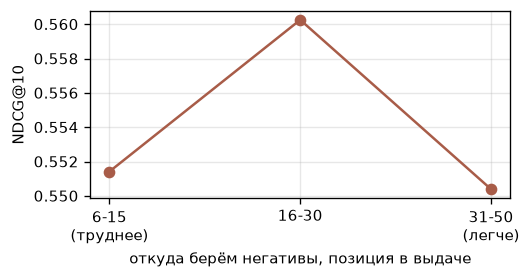

In [20]:
BANDS = ["ft_band_6_15", "ft_band_16_30", "ft_band_31_50"]
display(show(BANDS, cols=("Recall@10", "NDCG@10", "MRR@10")))

vals = [res[b]["NDCG@10"] for b in BANDS if b in res]
if len(vals) == len(BANDS):
    plt.figure(figsize=(4.5, 2.4))
    plt.plot(range(3), vals, "o-", color="#a85c48")
    plt.xticks(range(3), ["6-15\n(труднее)", "16-30", "31-50\n(легче)"])
    plt.xlabel("откуда берём негативы, позиция в выдаче")
    plt.ylabel("NDCG@10"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

Перевёрнутая парабола, оптимум посередине: слишком трудные негативы вредят, слишком
лёгкие ничему не учат. Это же объясняет провал предыдущей гипотезы — человеческие
негативы сидели на медианной позиции 7, в зоне «слишком трудно».

In [21]:
show(["ft_inbatch_bs96", "ft_best"], cols=("Recall@10", "Recall@100", "NDCG@10", "MRR@10"))

""


## 6. Кросс-энкодер-реранкер

У двубашенной модели есть потолок, и он архитектурный: всё взаимодействие запроса с
документом сжато в одно скалярное произведение. Поэтому поиск строят **воронкой** —
быстрый этап отбирает кандидатов, точный и дорогой переставляет верхушку. Разделы 6 и 7
про то, во что это обходится по времени.

**Кросс-энкодер** получает пару целиком — `[CLS] запрос [SEP] документ [SEP]` — и выдаёт
одно число. Внимание работает между токенами запроса и документа, поэтому он видит то,
чего двубашенная модель увидеть не может: например, что в документе стоит именно та
дата, о которой спрашивают. Скор зато нельзя посчитать заранее, так что пускают его на
топ-50 быстрого поиска, и меняет он только порядок внутри.

Сравниваю три семейства лоссов ранжирования на одних данных. **pointwise**
(`BinaryCrossEntropy`) знает только метку отдельной пары, о конкуренции документов
внутри запроса — ничего. **pairwise** (`RankNet`) штрафует за каждую переставленную
пару, все пары равноценны. **listwise** (`LambdaLoss`) — то же, но вес пары умножен на
изменение NDCG: ошибка на позициях 1–2 дороже, чем на 40–41.

In [22]:
rr_path = os.path.join(nova.MINI, "reranker.json")
rr = nova.load_json(rr_path) if os.path.exists(rr_path) else None
if rr:
    display(pd.DataFrame(rr["losses"]).round(4))
    base, best = rr["base_test"], [x for x in rr["losses"] if x["лосс"] == rr["best"]][0]
    per_pair = best["мс/запрос"] / rr["top_n"]
    print(f"базовая выдача:            NDCG@10={base['NDCG@10']:.4f}  MRR@10={base['MRR@10']:.4f}")
    print(f"после реранкера ({rr['best']}): NDCG@10={best['NDCG@10']:.4f}  MRR@10={best['MRR@10']:.4f}")
    print(f"\nцена: {best['мс/запрос']:.1f} мс на запрос, то есть {per_pair:.2f} мс на пару")
    print(f"тот же кросс-энкодер по всему корпусу (150k): "
          f"{per_pair * 150_000 / 1000:.0f} с на ОДИН запрос")

Последняя строчка — весь смысл двухэтажной архитектуры одним числом: тот же
кросс-энкодер по всему корпусу превращает поиск из миллисекунд в минуты.

## 7. ANN-индекс

Точный перебор по 150 тысячам векторов на ноутбуке возможен, по 150 миллионам — нет.
Беру **HNSW**: многослойный граф, где нижний слой содержит все точки, а каждый
следующий — прореженное подмножество предыдущего. Верхние слои дают длинные прыжки,
нижние — точную доводку. Главная ручка — **`efSearch`**, размер очереди кандидатов.

Ниже два разных recall: **относительно точного перебора** — качество самого индекса( многослойного графа),
поисковый Recall@k — против человеческой разметки. Индекс может терять 3% соседей, а
конечная метрика не двинуться: теряются нерелевантные с хвоста.

,efSearch,recall_vs_exact,ms_per_query,NDCG@10,Recall@100
0,160,0.9619,0.8182,0.5530,0.8862
1,320,0.9879,1.4447,0.5533,0.8895
2,640,0.9972,2.5934,0.5533,0.8896


корпус: 150,000 векторов размерности 312, индекс построен за 23.4с
точный перебор: 0.33 мс/запрос батчем на MPS, 7.18 мс/запрос по одному на CPU


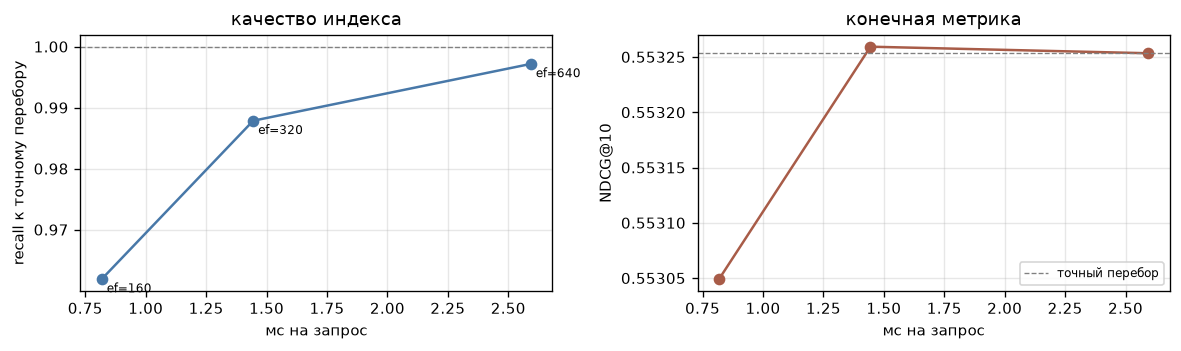

In [23]:
ann_path = os.path.join(nova.MINI, "ann_ft_mined_bs64.json")
ann = nova.load_json(ann_path) if os.path.exists(ann_path) else None
if ann:
    df_ann = pd.DataFrame(ann["grid"])
    display(df_ann.round(4))
    print(f"корпус: {ann['corpus_size']:,} векторов размерности {ann['dim']}, "
          f"индекс построен за {ann['build_seconds']:.1f}с")
    print(f"точный перебор: {ann['exact_batched_ms']:.2f} мс/запрос батчем на MPS, "
          f"{ann['exact_single_ms']:.2f} мс/запрос по одному на CPU")

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(df_ann["ms_per_query"], df_ann["recall_vs_exact"], "o-", color="#4878a8")
    for _, r in df_ann.iterrows():
        ax[0].annotate(f"ef={int(r['efSearch'])}", (r["ms_per_query"], r["recall_vs_exact"]),
                       fontsize=7, xytext=(3, -8), textcoords="offset points")
    ax[0].axhline(1.0, color="gray", ls="--", lw=0.8)
    ax[0].set_xlabel("мс на запрос"); ax[0].set_ylabel("recall к точному перебору")
    ax[0].set_title("качество индекса"); ax[0].grid(alpha=0.3)

    ax[1].plot(df_ann["ms_per_query"], df_ann["NDCG@10"], "o-", color="#a85c48")
    ax[1].axhline(res["ft_mined_bs64"]["NDCG@10"], color="gray", ls="--", lw=0.8,
                  label="точный перебор")
    ax[1].set_xlabel("мс на запрос"); ax[1].set_ylabel("NDCG@10")
    ax[1].set_title("конечная метрика"); ax[1].grid(alpha=0.3); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()

## 8. LLM-судья

Тот самый вопрос, с которого всё началось: можно ли посадить модель на место асессора.
Все ставят и верят, число согласия почти никто не публикует — вот его я и считаю.

Ставка понятная. Если судья согласен с людьми достаточно, чтобы ему верить, разметку
можно печатать: почистить намайненные негативы от ложных (в разделе 4 видно, что 4% из
них человек уже признал позитивами, а сколько прячется среди 80% неразмеченных, никто не
знает), разметить пары, которых в MIRACL нет, обучаться на порядок большем объёме. И
тогда стена, с которой проект начался, исчезает. Если согласия нет — ветка закрыта, и
это тоже ответ.

Судья — `qwen2.5:7b` в квантовании Q4_K_M через локальный Ollama: веса хранятся примерно
в 4 битах вместо 16, модель занимает 4.7 ГБ вместо 15 и влезает в ноутбук ценой
небольшой потери качества. Детерминизм — `temperature=0`, фиксированный seed, вывод по
JSON-схеме. Рубрика на четыре градации: бинарный вопрос заставлял бы модель в
пограничных случаях решать наугад, а границу я подберу потом, по согласию с людьми.

In [24]:
print(J.RUBRIC)
print("\n" + "=" * 70 + "\nПРОМПТ, ВЕРСИЯ 1\n" + "=" * 70)
print(J.PROMPT_V1.format(rubric="<рубрика выше>", query="<запрос>", passage="<пассаж>"))

0 — не относится к вопросу: другая тема или другой объект.
1 — та же тема, но ответа на вопрос нет: упоминается тот же объект, однако
    искомого факта в тексте не найти.
2 — ответ есть частично: можно извлечь часть искомого факта или ответ дан
    неявно, через смежные сведения.
3 — прямой ответ: в тексте явно есть тот факт, который спрашивают.

ПРОМПТ, ВЕРСИЯ 1
Ты оцениваешь релевантность текста поисковому запросу.

Шкала:
<рубрика выше>

Запрос: <запрос>

Текст: <пассаж>

Оценка:


Первая версия намеренно голая: сначала надо посмотреть, где судья ошибается сам по
себе, и только потом чинить промпт по фактам.

Accuracy обманчива — судья, всегда отвечающий «релевантен», получит 50% на
сбалансированной выборке. Основная метрика — **каппа Коэна** $(p_o - p_e)/(1 - p_e)$,
где $p_o$ — доля совпадений, а $p_e$ — доля, которая вышла бы у двух независимых
разметчиков с теми же частотами ответов. То есть каппа вычитает случайное согласие:
0.4–0.6 умеренное, 0.6–0.8 существенное, выше 0.8 почти идеальное.

In [25]:
def cohen_kappa(a, b):
    labels = sorted(set(a) | set(b))
    n = len(a)
    p_o = sum(1 for x, y in zip(a, b) if x == y) / n
    p_e = sum((a.count(l) / n) * (b.count(l) / n) for l in labels)
    return (p_o - p_e) / (1 - p_e) if p_e != 1 else 0.0


# полное согласие -> 1, согласие только по случайности -> около 0
print("совпали полностью:", round(cohen_kappa([1, 0, 1, 0], [1, 0, 1, 0]), 3))
print("угадывание:       ", round(cohen_kappa([1, 0, 1, 0], [1, 1, 0, 0]), 3))

совпали полностью: 1.0
угадывание:        0.0


In [26]:
jv_path = os.path.join(nova.MINI, "judge_valid.json")
jv = nova.load_json(jv_path) if os.path.exists(jv_path) else {}
if jv:
    display(pd.DataFrame([
        {"версия промпта": k, "каппа": v["kappa"], "accuracy": v["accuracy"],
         "precision": v["precision"], "recall": v["recall"], "F1": v["f1"],
         "граница оценки": v["threshold"]}
        for k, v in sorted(jv.items(), key=lambda x: -x[1]["kappa"])]).round(3))

,версия промпта,каппа,accuracy,precision,recall,F1,граница оценки
0,v1:plain,0.48,0.74,0.767,0.69,0.726,2


Каппа 0.48 — умеренное согласие. Разбор ошибок дал две закономерности, и обе не те, что
я предполагал. **Ложные срабатывания (63) — путаница сущностей:** судья находит фразу,
которая *по форме* отвечает на вопрос, и не проверяет, про тот ли она объект.

| запрос | что подсунуто | почему судья купился |
|---|---|---|
| день города в **Калуге** | статья про **Калуш** | «отмечает день города в 3-ю субботу сентября» |
| высота **Останкинской** башни | другая московская башня | «Высота башни — 258 метров» |
| когда основан **Ватикан** | **Ватиканский секретный архив** | «официально основан в 1610» |

**Пропуски (93) — требование дословности:** «Принимал ли КВ-85 участие в боевых
действиях?» при тексте «свою задачу КВ-85 в основном выполнял». А длина пассажа, на
которую я грешил заранее, ни при чём: на текстах длиннее 800 символов точность даже
выше, 0.753 против 0.725.

Версию 2 промпта переписал под найденное: проверка сущности перед проверкой факта, запрет
засчитывать похожие названия, разрешение неявных ответов.

In [27]:
print(J.PROMPT_V2.format(rubric="<рубрика выше>", query="<запрос>", passage="<пассаж>"))

Ты — асессор поисковой выдачи. Реши, содержит ли ТЕКСТ ответ на ВОПРОС.

Шкала:
<рубрика выше>

Порядок рассуждения — строго такой:

ШАГ 1. Определи, о каком именно объекте спрашивают: конкретный город, человек,
здание, организация, произведение, событие. Выпиши его для себя.

ШАГ 2. Проверь, что ТЕКСТ про ЭТОТ ЖЕ объект. Это главное правило.
Похожее название — не то же самое: Калуга и Калуш разные города, Ватикан и
Ватиканский архив разные объекты, Останкинская башня и другая башня в Москве
разные сооружения. Если текст про другой объект, оценка 0 — даже если в нём
есть фраза, которая по форме выглядит ответом на вопрос.

ШАГ 3. Только если объект тот же — проверь, есть ли искомый факт.
Ответ засчитывается, даже если он сформулирован не теми словами и подан
неявно, но однозначно следует из написанного. Требовать дословную
формулировку не надо.

ШАГ 4. Поставь оценку:
   3 — тот же объект, искомый факт есть (явно или однозначно следует);
   2 — тот же объект, факт есть частично или отв

In [28]:
jt_path = os.path.join(nova.MINI, "judge_test.json")
jt = nova.load_json(jt_path) if os.path.exists(jt_path) else {}
if jt:
    display(pd.DataFrame([
        {"версия промпта": k, "каппа": v["kappa"], "accuracy": v["accuracy"],
         "precision": v["precision"], "recall": v["recall"], "F1": v["f1"]}
        for k, v in sorted(jt.items(), key=lambda x: -x[1]["kappa"])]).round(3))

## 9. Дистилляция судьи

Судья заводился ради объёма, а на объёме он и ломается: секунда с лишним на пару — это
неделя счёта на сто тысяч пар, то есть ровно то, от чего мы уходили. Поэтому учу
`rubert-tiny2` в режиме кросс-энкодера предсказывать оценку судьи. Смотрю согласие
студента с учителем — это потолок того, что он мог выучить, — и отдельно с людьми:
учитель тоже ошибается, и студент может унаследовать его ошибки.

In [29]:
js_path = os.path.join(nova.MINI, "judge_student_eval.json")
js = nova.load_json(js_path) if os.path.exists(js_path) else None
if js:
    display(pd.DataFrame([js]).T.rename(columns={0: "значение"}))

## 10. Итоговая таблица

Все строки — один и тот же мини-корпус и один и тот же набор тестовых запросов.

In [30]:
res = nova.load_json(nova.RESULTS_PATH)
FINAL = ["BM25", "rubert-tiny2, zero-shot", "ft_inbatch_bs64", "ft_mined_bs64",
         "ft_best"] + [k for k in res if k.startswith("+ реранкер")] + \
        ["multilingual-e5-small, zero-shot"]
show([k for k in FINAL if k in res])

,подход,Recall@10,Recall@100,NDCG@10,MRR@10
0,BM25,0.6504,0.8558,0.5142,0.5400
1,"rubert-tiny2, без дообучения",0.1796,0.4577,0.1335,0.1615
2,"дообучен, негативы только из батча (батч 64)",0.6699,0.8887,0.5369,0.5903
3,дообучен + сложные негативы (батч 64),0.6869,0.8898,0.5533,0.6063
4,"multilingual-e5-small, без дообучения",0.8835,0.9941,0.7595,0.7905


## 11. Разбор ошибок руками

Средние числа скрывают, что именно ломается.

запросов: 947
  полный провал (NDCG@10 = 0):   119 (12.6%)
  идеальная выдача (NDCG@10 = 1): 139 (14.7%)


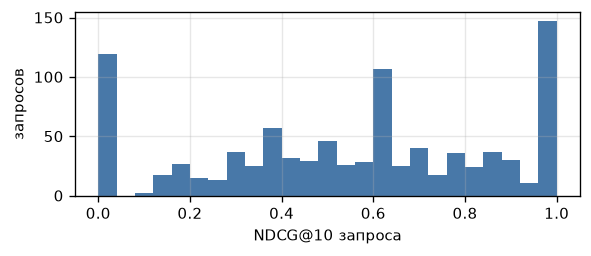

In [31]:
run_best = {q: v for q, v in R.load_run("ft_mined_bs64", "test").items()
            if q in set(sp["test_qids"])}
per_q = nova.per_query_metric(run_best, qrels_dev, "ndcg", 10)
vals = np.array(list(per_q.values()))
print(f"запросов: {len(per_q)}")
print(f"  полный провал (NDCG@10 = 0):   {int((vals == 0).sum())} ({100 * (vals == 0).mean():.1f}%)")
print(f"  идеальная выдача (NDCG@10 = 1): {int((vals == 1).sum())} ({100 * (vals == 1).mean():.1f}%)")

plt.figure(figsize=(5, 2.2))
plt.hist(vals, bins=25, color="#4878a8")
plt.xlabel("NDCG@10 запроса"); plt.ylabel("запросов"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Распределение бимодальное: модель либо находит ответ, либо не находит совсем. Значит
средний NDCG сам по себе мало о чём говорит — смотреть надо, чем отличаются два горба.

In [32]:
by_type = A.metric_by_query_type(run_best, qrels_dev, topics, 10)
pd.DataFrame([{"тип вопроса": t, "запросов": d["n"], "NDCG@10": round(d["ndcg"], 4)}
              for t, d in by_type.items() if d["n"] >= 15]).sort_values("NDCG@10")

,тип вопроса,запросов,NDCG@10
8,что,25,0.3593
7,как называется,32,0.4161
4,какой,77,0.4678
3,кто (человек),93,0.4958
5,как (способ),49,0.5434
0,прочее,307,0.5708
1,когда (дата),200,0.5864
2,сколько (число),99,0.5916
6,где (место),43,0.6599


## 12. Выводы

**Дообучение под домен окупается.** Десять тысяч пар снимают `rubert-tiny2` с уровня «в
разы хуже BM25» до «уверенно лучше BM25», а само обучение занимает пару минут. То есть
дорого стоит разметка, а не счёт — и потому вопрос про судью не праздный.

**Но оно не заменяет предобучение.** `multilingual-e5-small` без всякого дообучения
остаётся впереди. Вывод не «дообучение не помогает», а «дообучение маленькой модели на
десяти тысячах примеров не догоняет модель, которую учили под retrieval на сотнях
миллионов пар». Для исходной бытовой задачи это значит простое: брать с полки e5 и
доучивать её, а не тащить tiny с нуля.

Что дальше: дообучать e5-small вместо rubert-tiny2; учить студента на скорах учителя
(MarginMSE), а не на бинарных метках; перемайнивать негативы выдачей уже дообученной
модели, как в ANCE. **[ОЦЕНКА]** Переход e5-small → e5-base даёт по таблице E5 +0.024
NDCG@10 на полном MIRACL-ru, e5-large — ещё +0.06; не гонял, это часы кодирования
корпуса ради предсказуемого вывода.

## Приложение: сводка по гипотезам

In [33]:
pd.DataFrame([
    ("урезание корпуса в 64 раза сильно облегчает задачу", "подтвердилась",
     "наш BM25 даёт NDCG@10 0.514 против 0.334 на полном корпусе"),
    ("дообучение под домен сильно обходит zero-shot", "подтвердилась",
     "0.134 → 0.553 NDCG@10, вчетверо; обходит и BM25"),
    ("сложные негативы дают прирост поверх in-batch", "подтвердилась",
     "+0.016 NDCG@10 при батче 64"),
    ("больший батч в MNRL даёт больше негативов и лучше качество",
     "подтвердилась после починки эксперимента",
     "при фиксированном LR выходило наоборот; с масштабированным LR "
     "0.510 → 0.537 → 0.550 → 0.559 для батчей 16/64/128/256"),
    ("человеческие негативы лучше намайненных, ведь среди них нет ложных",
     "ОПРОВЕРГНУТА",
     "0.501 против 0.540; человеческие оказались труднее (в топ-10 73% против 58%)"),
    ("трудность негатива имеет оптимум", "подтвердилась",
     "0.5514 → 0.5603 → 0.5504 для полос 6-15 / 16-30 / 31-50"),
], columns=["гипотеза", "итог", "чем кончилось"])

,гипотеза,итог,чем кончилось
0,урезание корпуса в 64 раза сильно облегчает задачу,подтвердилась,наш BM25 даёт NDCG@10 0.514 против 0.334 на полном корпусе
1,дообучение под домен сильно обходит zero-shot,подтвердилась,"0.134 → 0.553 NDCG@10, вчетверо; обходит и BM25"
2,сложные негативы дают прирост поверх in-batch,подтвердилась,+0.016 NDCG@10 при батче 64
3,больший батч в MNRL даёт больше негативов и лучше качество,подтвердилась после починки эксперимента,при фиксированном LR выходило наоборот; с масштабированным LR 0.510 → 0.537 → 0.550 → ...
4,"человеческие негативы лучше намайненных, ведь среди них нет ложных",ОПРОВЕРГНУТА,0.501 против 0.540; человеческие оказались труднее (в топ-10 73% против 58%)
5,трудность негатива имеет оптимум,подтвердилась,0.5514 → 0.5603 → 0.5504 для полос 6-15 / 16-30 / 31-50


## Приложение: где пришлось повозиться с железом

**Кеш аллокатора MPS распухает на обучении.** Шаг вырос с 0.4 секунды до 14, машина ушла
в своп. `sentence-transformers` паддит батч по самой длинной строке в нём, форма тензора
меняется почти каждый шаг, а аллокатор MPS резервирует блоки под каждую новую форму —
кеш набрал 13 ГБ. Лечится `torch.mps.empty_cache()` раз в 10–25 шагов. Диагностику это
уводит не туда: `ps` MPS-аллокации не показывает, память выглядит как «wired без
владельца», и я сначала грешил на многодневный аптайм.

**Матрица внимания весит `batch × heads × L² × 4` байта** — при батче 256 и длине 512 это
3.2 ГБ, отсюда длина 256 токенов (покрывает 90% пассажей целиком).